## Plot Abil Output

In [ ]:
import cartopy.crs as ccrs
import cartopy as cart
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
from yaml import load, Loader
from datetime import datetime


In [4]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "environment.yml").exists():
            return path
    raise FileNotFoundError("Could not find project root containing environment.yml")


PROJECT_ROOT = find_project_root()
CONFIG_PATH = PROJECT_ROOT / "1-phase example" / "regressor.yml"

with CONFIG_PATH.open('r') as f:
    model_config = load(f, Loader=Loader)

run_name = 'pp_na'
current_date = datetime.today().strftime('%Y-%m-%d')
file = current_date + '_mean'
post_dir = PROJECT_ROOT / model_config['path_out'] / run_name / 'posts'
ds_mean = xr.open_dataset(post_dir / f"{file}.nc")
varname = 'Primary_Production'


### Create of map of surface pimary production in April

/home/joost/miniconda3/envs/abil-tutorial-env/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/joost/miniconda3/envs/abil-tutorial-env/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


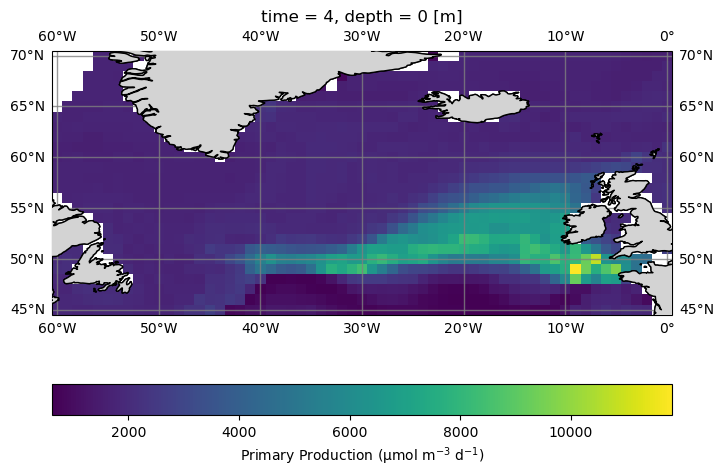

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and land fill color
ax.coastlines()
ax.add_feature(cart.feature.LAND, 
               linewidth = 1, 
               zorder=3, 
               edgecolor='k', 
               facecolor="lightgray")

ax.gridlines(draw_labels=True, 
             linewidth=1,
             color='gray',
             alpha=0.8,
             linestyle='-',
             zorder=1
)
p = ds_mean[varname].sel(
    depth=0, 
    time=4
    ).plot(
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,)


cbar = plt.colorbar(p, 
                    location='bottom', 
                    label="Primary Production (µmol m$^{-3}$ d$^{-1}$)")

### Create map of depth integrated annual production

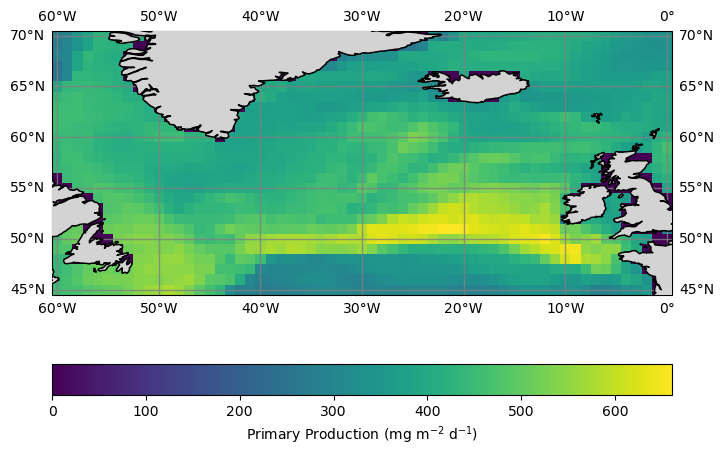

In [6]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and land fill color
ax.coastlines()
ax.add_feature(cart.feature.LAND, 
               linewidth = 1, 
               zorder=3, 
               edgecolor='k', 
               facecolor="lightgray")

ax.gridlines(draw_labels=True, 
             linewidth=1,
             color='gray',
             alpha=0.8,
             linestyle='-',
             zorder=1
)

conversion_factor = 12.01e-3 # µmol to mg of C (C atomic weight)
depth_width = 5
depth_integrated_pp = ds_mean[varname].sum(dim=["depth"]).mean(dim="time") * depth_width * conversion_factor

p = depth_integrated_pp.plot(
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,)


cbar = plt.colorbar(p, 
                    location='bottom', 
                    label="Primary Production (mg m$^{-2}$ d$^{-1}$)")

### Plot timeseries of production

In [7]:
# Load confidence intervals
file_LL = '2026-04-28_ci95_LL'
ds_LL = xr.open_dataset(post_dir / f"{file_LL}.nc")
file_UL = '2026-04-28_ci95_UL'
ds_UL = xr.open_dataset(post_dir / f"{file_UL}.nc")


FileNotFoundError: [Errno 2] No such file or directory: '/home/joost/Abil_tutorial/ModelOutput/pp_na/posts/2026-04-28_ci95_LL.nc'

In [ ]:
# Constants
R = 6.371e6             # Earth radius (m)
dlat = np.deg2rad(1.0)
dlon = np.deg2rad(1.0)
dz = 5.0                # m
molar_mass_C = 12.011   # g/mol
umol_to_mol = 1e-6
g_to_Tg = 1e-12
days_in_month = 30.44
conv_factor = molar_mass_C * umol_to_mol * g_to_Tg * days_in_month  # 12.011e-18

# Grid-cell area (broadcast to 2D lat/lon)
lat = np.deg2rad(ds_mean['lat'])
area = (R**2 * dlat * dlon * np.cos(lat)).broadcast_like(ds_mean[varname].isel(time=0, depth=0))

try:
    time_values = ds_mean['time'].values
except:
    time_values = np.arange(ds_mean[varname].shape[0])

mean_filled = xr.where(
    ds_mean[varname].isnull() & ds_mean[varname].notnull().any(dim='time'),
    0,
    ds_mean[varname]
)
LL_filled = xr.where(
    ds_LL[varname].isnull() & ds_LL[varname].notnull().any(dim='time'),
    0,
    ds_LL[varname]
)
UL_filled = xr.where(
    ds_UL[varname].isnull() & ds_UL[varname].notnull().any(dim='time'),
    0,
    ds_UL[varname]
)

# Keep time dimension even if biome is empty
mean_vals = mean_filled.mean(dim=['lat','lon','depth'], skipna=True, keepdims=False)
LL_vals   = LL_filled.mean(dim=['lat','lon','depth'], skipna=True, keepdims=False)
UL_vals   = UL_filled.mean(dim=['lat','lon','depth'], skipna=True, keepdims=False)

# Convert to numpy, ensuring it matches time_values length
mean_vals = mean_vals.reindex(time=time_values, fill_value=np.nan).values
LL_vals   = LL_vals.reindex(time=time_values, fill_value=np.nan).values
UL_vals   = UL_vals.reindex(time=time_values, fill_value=np.nan).values

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(time_values, mean_vals, color="black", linewidth=2)
ax.fill_between(time_values, LL_vals, UL_vals, alpha=1)
ax.set_ylabel(r'Mean Primary Production (µmol m$^{-3}$ d$^{-1}$)')

ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.set_xticks(np.arange(1, 13, 2))
ax.set_xlabel('Time (months)')